In [117]:
from transformers import AutoTokenizer, AutoModel
import torch
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import defaultdict
import pickle as pkl

In [119]:

# Fallback simple tokenizer if punkt is unavailable
try:
    import nltk
    nltk.data.find('tokenizers/punkt')
    from nltk.tokenize import word_tokenize
    tokenize = word_tokenize
except Exception:
    tokenize = lambda text: text.split()

def clean_text(text: str) -> str:
    """Lowercase, collapse whitespace, remove non-alphanumeric (retaining Telugu)."""
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-z0-9\u0C00-\u0C7F ]', '', text)
    return text.strip()

def load_mind_small(news_path: str, behaviors_path: str):
    # Define columns (no header in file)
    news_cols = ['news_id','cat_subcat','title','abstract','title_entities','abstract_entities']
    news = pd.read_csv(news_path, sep='\t', names=news_cols, header=None, dtype=str)
    
    # Drop any accidental header row
    if news.iloc[0]['news_id'].lower().startswith('newsid'):
        news = news.iloc[1:].reset_index(drop=True)
    
    # Split category/subcategory on first slash
    split = news['cat_subcat'].str.split('/', n=1, expand=True)
    news['category'] = split[0]
    news['subcategory'] = split[1].fillna('')
    news.drop(columns=['cat_subcat'], inplace=True)
    
    # Clean & tokenize text fields
    for col in ['title','abstract']:
        news[col] = news[col].fillna('').apply(clean_text)
        news[f'{col}_tokens'] = news[col].apply(tokenize)
    
    # --- Behaviors ---
    behav_cols = ['impr_id','user_id','timestamp','history','impressions']
    beh = pd.read_csv(behaviors_path, sep='\t', names=behav_cols, header=None, dtype=str)
    
    # Drop header row if present
    if beh.iloc[0]['impr_id'].lower().startswith('impressionid'):
        beh = beh.iloc[1:].reset_index(drop=True)
    
    # Parse history field
    beh['history'] = beh['history'].fillna('').apply(lambda s: s.split())
    
    # Parse impressions into ids & labels
    def parse_imps(s):
        ids, labels = [], []
        for p in str(s).split():
            if '-' in p:
                nid, lbl = p.split('-', 1)
                ids.append(nid)
                labels.append(int(lbl))
        return pd.Series({'imp_ids': ids, 'imp_labels': labels})
    
    imp_df = beh['impressions'].apply(parse_imps)
    beh = pd.concat([beh.drop(columns=['impressions']), imp_df], axis=1)
    
    return news, beh

# Example usage:
# news_df, beh_df = load_mind_small(
#     '/Users/.../MINDsmall_train/news.tsv',
#     '/Users/.../MINDsmall_train/behaviors.tsv'
# )



In [107]:
mind_news, mind_beh = load_mind_small('/Users/harshadayiniakula/Desktop/RS/MINDsmall_train/news.tsv',
                                    '/Users/harshadayiniakula/Desktop/RS/MINDsmall_train/behaviors.tsv')
ent_emb = load_embeddings('/Users/harshadayiniakula/Desktop/RS/MINDsmall_train/entity_embedding.vec')
rel_emb = load_embeddings('/Users/harshadayiniakula/Desktop/RS/MINDsmall_train/relation_embedding.vec')

# Inspect sizes
print(f"News: {mind_news.shape}, Behaviors: {mind_beh.shape}")
print(f"Entity embeddings: {len(ent_emb)}, Relation embeddings: {len(rel_emb)}")


News: (51282, 9), Behaviors: (156965, 6)
Entity embeddings: 26904, Relation embeddings: 1091


In [70]:
def clean_telugu_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-z0-9\u0c00-\u0c7f ]', '', text)
    return text.strip()

def load_and_analyze_telugu_news_parquet(train_path: str, val_path: str, test_path: str):
    # Load
    train = pd.read_parquet(train_path)
    val = pd.read_parquet(val_path)
    test = pd.read_parquet(test_path)
    
    # Merge splits
    full = pd.concat([train, val, test], axis=0).reset_index(drop=True)
    
    # Clean
    full['headline_clean'] = full['headline'].fillna('').apply(clean_telugu_text)
    full['article_clean'] = full['article'].fillna('').apply(clean_telugu_text)
    
    # Basic stats
    stats = {
        'num_samples': len(full),
        'headline_avg_len': full['headline_clean'].apply(lambda x: len(x.split())).mean(),
        'article_avg_len': full['article_clean'].apply(lambda x: len(x.split())).mean(),
        'headline_median_len': full['headline_clean'].apply(lambda x: len(x.split())).median(),
        'article_median_len': full['article_clean'].apply(lambda x: len(x.split())).median(),
        'empty_headlines': (full['headline_clean'].str.strip() == '').sum(),
        'empty_articles': (full['article_clean'].str.strip() == '').sum(),
    }
    
    return full, stats

def plot_text_length_distribution(full_df):
    """
    Plot histogram of headline and article token lengths.
    """
    headline_lengths = full_df['headline_clean'].apply(lambda x: len(x.split()))
    article_lengths = full_df['article_clean'].apply(lambda x: len(x.split()))
    
    plt.figure(figsize=(14,5))
    
    plt.subplot(1,2,1)
    plt.hist(headline_lengths, bins=50, color='blue', alpha=0.7)
    plt.title('Headline Length Distribution')
    plt.xlabel('Number of tokens')
    plt.ylabel('Number of headlines')
    plt.xlim(0, 100)
    
    plt.subplot(1,2,2)
    plt.hist(article_lengths, bins=50, color='green', alpha=0.7)
    plt.title('Article Length Distribution')
    plt.xlabel('Number of tokens')
    plt.ylabel('Number of articles')
    plt.xlim(0, 2000)
    
    plt.tight_layout()
    plt.show()


{'num_samples': 102332, 'headline_avg_len': 3.70381698784349, 'article_avg_len': 135.90308994253996, 'headline_median_len': 4.0, 'article_median_len': 103.0, 'empty_headlines': 5962, 'empty_articles': 5962}


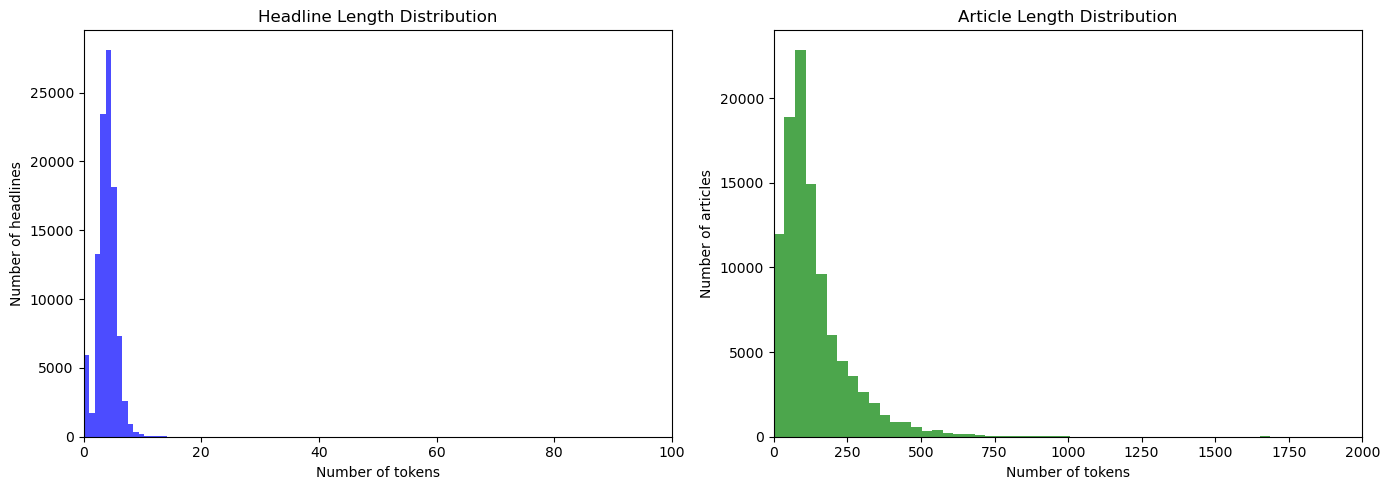

In [23]:
full_telugu, telugu_stats = load_and_analyze_telugu_news_parquet(
    '/Users/harshadayiniakula/Desktop/RS/telugu/train-00000-of-00001.parquet',
    '/Users/harshadayiniakula/Desktop/RS/telugu/val-00000-of-00001.parquet',
    '/Users/harshadayiniakula/Desktop/RS/telugu/test-00000-of-00001.parquet'
)

print(telugu_stats)
plot_text_length_distribution(full_telugu)


In [25]:
full_telugu['article_clean'] = full_telugu['article_clean'].fillna('').apply(lambda x: x.strip())
full_telugu['headline_clean'] = full_telugu['headline_clean'].fillna('').apply(lambda x: x.strip())


In [27]:
initial_len = len(full_telugu)
full_telugu = full_telugu[full_telugu['article_clean'] != ''].copy()
final_len = len(full_telugu)

In [58]:
print(full_telugu['article_clean'])

0         కుల్దీప్అక్షర్ మధ్య పోటీ27 నుంచి బంగ్లాతో రెండ...
1         మర్చంట్ బ్యాంకర్లే సూత్రదారులు నిగ్గు తేల్చిన ...
2         ముంబై దేశీయ స్టాక్ మార్కెట్లో మళ్లీ రికార్డుల ...
3         హైదరాబాద్ ఆంధ్రజ్యోతి పారాలింపిక్స్లో కాంస్య ప...
4         వచ్చే రెండేళ్లలో కొత్తగా 200 స్టోర్లుహైదరాబాద్...
                                ...                        
102327    వైసీపీ హయాంలో కొత్త పద్ధతి పదిరోజులు వైకుంఠ ద్...
102328    సీఎం రేవంత్ కేంద్ర మంత్రి కిషన్రెడ్డిహైదరాబాద్...
102329    అమరావతి జనవరి 8 ఆంధ్రజ్యోతి తిరుపతిలో జరిగిన ఘ...
102330    తిరుపతి తొక్కిసలాట తీవ్ర విషాదాన్ని నింపిందని ...
102331    తిరుపతిలో తొక్కిసలాట ఘటనపై ప్రధాని మోదీ తీవ్ర ...
Name: article_clean, Length: 96370, dtype: object


In [29]:
print(initial_len, final_len)

102332 96370


5962 is the number of empty articles
96370 is the remaining rows

In [40]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)  # Replace multiple spaces with one
    text = re.sub(r'[^a-z0-9\u0c00-\u0c7f ]', '', text)  # Keep Telugu + English alphanumerics
    return text.strip()

# Apply cleaning to headline and article
full_telugu['headline_clean'] = full_telugu['headline_clean'].apply(clean_text)
full_telugu['article_clean'] = full_telugu['article_clean'].apply(clean_text)

print("Finished deep cleaning headlines and articles.")


Finished deep cleaning headlines and articles.


In [60]:
# 1. Combine headline and article into a new field
full_telugu['full_text'] = full_telugu['headline_clean'] + ' ' + full_telugu['article_clean']

# 2. Remove any accidental double spaces after combining
full_telugu['full_text'] = full_telugu['full_text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())



Example combined text:

ఎస్ఎంఈ ఐపీఓల్లో మాయ మర్చంట్ బ్యాంకర్లే సూత్రదారులు నిగ్గు తేల్చిన సెబీ దర్యాప్తున్యూఢిల్లీ ఎస్ఎంఈ పబ్లిక్ ఇష్యూలు ఐపీఓ భారీగా సబ్స్క్రిప్షన్ కావడం వెనక పెద్ద దందానే నడుస్తోంది కొన్ని సంస్థలు హై నెట్వర్త్ ఇన్వెస్టర్ల హెచ్ఎన్ఐ సాయంతో మర్చంట్ బ్యాంకర్లే ఈ దందా నడిపిస్తున్నట్టు సెబీ దర్యాప్తులో తేలినట్టు సమాచారం ఈ సంస్థలు హై నెట్వర్త్ ఇన్వెస్టర్లు పెద్దమొత్తంలో ఐపీఓ షేర్లకు దరఖాస్తు చేయడం తీరా షేర్ల కేటాయింపు సమయానికి తమ బిడ్స్ వెనక్కి తీసుకుంటున్నట్టు పేరు వెల్లడించేందుకు ఇష్టపడని సెబీ అధికార వర్గాలు చెప్పాయి ఈ ఓవర్ సబ్స్క్రిప్షన్ చూసి ఇష్యూ బాగుందనే భావనతో రిటైల్ మదుపరులూ భారీగా దరఖాస్తు చేసి మోసపోతున్నట్టు సెబీ దర్యాప్తులో తేలింది ఈ దందాలో పాత్ర ఉన్న ఆరు మర్చంట్ బ్యాంకర్లని సెబీ ఇప్పటికే గుర్తించింది 15 శాతం ఫీజు సెబీ నిబంధనల ప్రకారం ఏ మర్చంట్ బ్యాంకింగ్ సంస్థా కంపెనీలు ఐపీఓ ద్వారా సమీకరించే నిధుల్లో ఒకటి నుంచి మూడు శాతానికి మించి ఫీజుగా వసూలు చేయకూడదు అయితే ఈ ఆరు మర్చంట్ బ్యాంకులు ఈ ఓవర్ సబ్స్క్రిప్షన్ దందా నడిపినందుకు తమ క్లయింట్ల నుంచి ఐపీఓ నిధుల్లో 15 శాతం వర

In [64]:
# 3. Quick check
print(f"Example combined text:\n\n{full_telugu['full_text'].iloc[0]}")
print(f"\nTotal combined articles prepared: {len(full_telugu)}")

Example combined text:

బుమ్రాకు విశ్రాంతి కుల్దీప్అక్షర్ మధ్య పోటీ27 నుంచి బంగ్లాతో రెండో టెస్టున్యూఢిల్లీ వరల్డ్ టెస్టు చాంపియన్షిప్ డబ్ల్యూటీసీ 202325 అంచెలో భాగంగా టీమిండియా ఆడే పది టెస్టుల్లో మొదటిదాన్ని ఘన విజయంతో ముగించింది బంగ్లాదేశ్తో జరిగిన ఈ మ్యాచ్లో ఏకంగా 280 పరుగుల తేడాతో నెగ్గి డబ్ల్యూటీసీ టేబుల్లో తమ అగ్రస్థానాన్ని మరింత పదిలపర్చుకుంది ఇక శుక్రవారం నుంచి కాన్పూర్లో చివరిదైన రెండో టెస్టు జరుగుతుంది వాస్తవానికి ఈ పది టెస్టుల్లో రోహిత్ సేన సగం మ్యాచ్లను గెలిచినా ఫైనల్లో చోటు ఖాయమే బంగ్లాతో రెండో టెస్టు తర్వాత స్వదేశంలో కివీస్తో మూడు టెస్టులు ఉంటాయి ఆ తర్వాత ఐదు టెస్టుల సిరీస్ కోసం భారత జట్టు ఆస్ట్రేలియా టూర్కు వెళ్లాల్సి ఉంటుంది అయితే అక్కడ ఆత్మవిశ్వాసంతో సిరీస్ను ఆరంభించేందుకు సొంత గడ్డపై మిగిలిన మూడు టెస్టులను గెలిచి ఒత్తిడి తగ్గించుకోవాలనుకుంటోందికాన్పూర్ పిచ్ను అనుసరించి ముగ్గురు స్పిన్నర్లతో వెళ్లాలనుకుంటే జట్టుకు ఓ పేసర్ దూరం కావాల్సిందే ఒకవేళ బుమ్రాకు రెస్ట్ ఇస్తే ఇబ్బంది లేదు కానీ తను ఆడితే మరో పేసర్ ఆకాశ్ దీప్పై వేటు పడే చాన్సుంది ఇక మూడో స్పిన్నర్ కోసం తుది జట్టుల

In [74]:
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print("Model and tokenizer loaded successfully.")

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

Model and tokenizer loaded successfully.


Embeddings for telugu articles

In [77]:
# 1. Prepare texts to encode
texts = full_telugu['full_text'].tolist()

# 2. Define a simple batch tokenizer + encoder loop
batch_size = 64  # Keep small if running on CPU

all_embeddings = []

model.eval()  # Set model to evaluation mode
with torch.no_grad():
    for start in range(0, len(texts), batch_size):
        end = start + batch_size
        batch_texts = texts[start:end]
        
        # Tokenize
        inputs = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt', max_length=512)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # Forward pass
        outputs = model(**inputs)
        last_hidden_states = outputs.last_hidden_state  # (batch_size, seq_len, hidden_dim)
        
        # Mean pooling: average over all token embeddings
        attention_mask = inputs['attention_mask']
        mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_states.size()).float()
        sum_embeddings = torch.sum(last_hidden_states * mask_expanded, dim=1)
        sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
        batch_embeddings = sum_embeddings / sum_mask
        
        # Move batch embeddings to CPU and save
        all_embeddings.append(batch_embeddings.cpu())

# 3. Stack all batches into one tensor
all_embeddings = torch.cat(all_embeddings, dim=0)

print(f"Finished embedding all articles. Final embeddings shape: {all_embeddings.shape}")


Finished embedding all articles. Final embeddings shape: torch.Size([96370, 384])


In [79]:
print(all_embeddings )

tensor([[ 0.4137,  0.2499,  0.3998,  ...,  0.1648,  0.6964,  0.0490],
        [ 0.4093,  0.2382,  0.4020,  ...,  0.1001,  0.6824,  0.0206],
        [ 0.4123,  0.3650,  0.2894,  ...,  0.1413,  0.5691, -0.0229],
        ...,
        [ 0.2678,  0.2740,  0.3350,  ...,  0.0260,  0.3545,  0.0414],
        [ 0.3533,  0.2644,  0.3420,  ..., -0.0538,  0.4675,  0.0426],
        [ 0.2385,  0.1904,  0.1944,  ...,  0.0442,  0.2853,  0.0551]])


In [81]:
torch.save(all_embeddings, '/Users/harshadayiniakula/Desktop/RS/telugu_article_embeddings.pt')

In [125]:
import pickle

In [127]:
telugu_news_ids = full_telugu['story_id'].tolist()

with open('/Users/harshadayiniakula/Desktop/RS/telugu_news_ids.pkl', 'wb') as f:
    pickle.dump(telugu_news_ids, f)

print(f"Saved {len(telugu_news_ids)} Telugu article IDs.")

Saved 96370 Telugu article IDs.


In [113]:
print(full_telugu)

        story_id                               headline  \
0        2481002                    బుమ్రాకు విశ్రాంతి!   
1        2481003                    ఎస్ఎంఈ ఐపీఓల్లో మాయ   
2        2481004                    సెన్సెక్స్ @ 85,000   
3        2481006        దీప్తికి రూ. కోటి అందజేసిన సీఎం   
4        2481007          విస్తరణ బాటలో  రామ్రాజ్ కాటన్   
...          ...                                    ...   
102327   2546134                        టోకెన్లతో తంటా!   
102328   2546132           తిరుపతి ఘటన దిగ్భ్రాంతికరం..   
102329   2546130  తీవ్ర ఆవేదన కలిగించింది: పవన్ కల్యాణ్   
102330   2546125     మృతుల కుటుంబాలకు సానుభూతి: రాహుల్    
102331   2546133           తొక్కిసలాట బాధాకరం: ప్రధాని    

                                                  article text  \
0       కుల్దీప్–అక్షర్ మధ్య పోటీ27 నుంచి బంగ్లాతో రెం...  NaN   
1       మర్చంట్ బ్యాంకర్లే సూత్రదారులు... నిగ్గు తేల్చ...  NaN   
2       ముంబై: దేశీయ స్టాక్ మార్కెట్లో మళ్లీ రికార్డుల...  NaN   
3       హైదరాబాద్ (ఆంధ్రజ్య